## Bagging vs RF
If features were sampled once per tree: bagging (TREE LEVEL SAMPLING)
- Tree gets, say, [X1, X3, X7] for its entire lifetime
- Every node in that tree competes among the same 3 features
- If X1 is dominant, it wins at the root, and X3, X7 share the leftovers
- Two trees that both drew X1 will have **similar root splits → similar structure
  → high correlation**

By sampling fresh at **every node**: rf (NODE LEVEL SAMPLING)
- X1 is only present at a node with probability `m/p`
- Even within a single tree, different branches explore different features
- Across trees, the dominant feature cannot structurally dominate
- Result: genuinely diverse trees have low ρ which mean they have low ensemble variance

The node-level resampling is what makes the decorrelation **persistent throughout
the entire depth of every tree**, not just at the root.

In [10]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
     

In [11]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [12]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()
     

(100, 6)


,col1,col2,col3,col4,col5,target
0,2.129827,0.795198,-2.503568,0.048649,-1.801701,1
1,-2.520901,-1.007523,-2.526250,-1.848251,-0.861708,1
2,0.327465,0.839474,-0.010125,2.217782,0.289665,0
3,0.937726,0.104745,1.526496,1.462840,-0.699730,0
4,1.545147,-0.731667,-0.521894,1.102871,1.662179,1


In [13]:
bag = BaggingClassifier(max_features=2)

In [14]:
bag.fit(df.iloc[:,:5],df.iloc[:,-1])

BaggingClassifier(max_features=2)

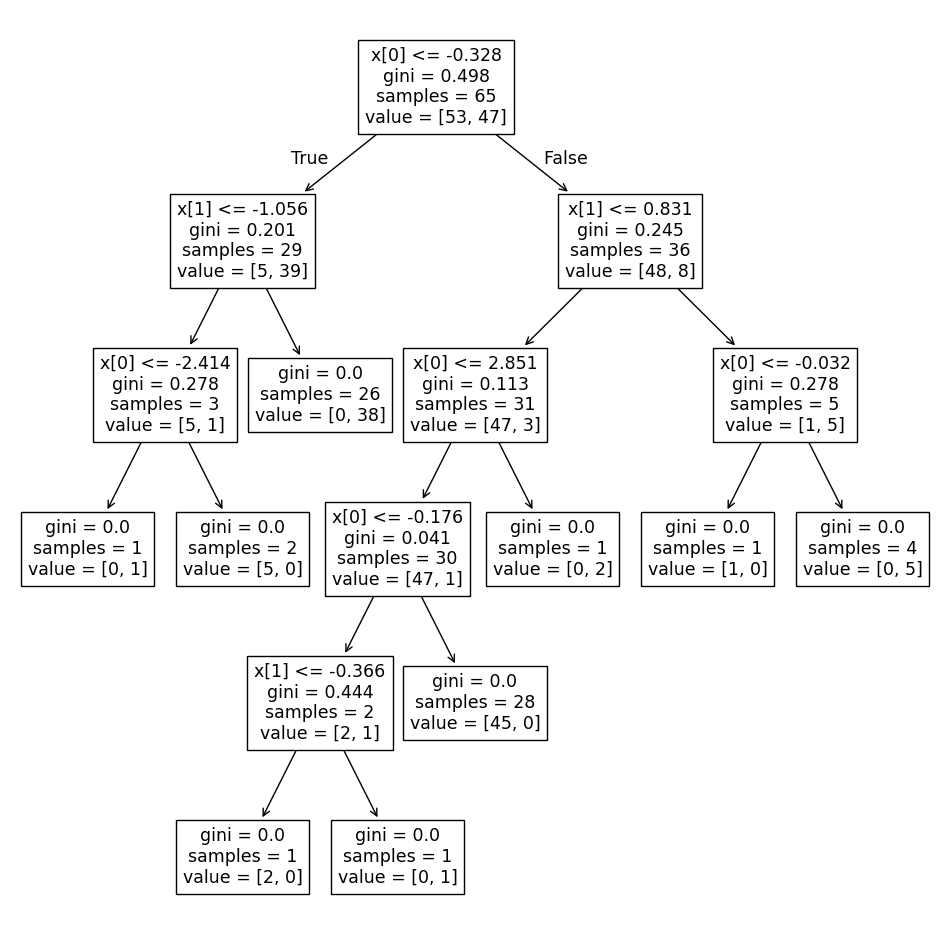

In [15]:
plt.figure(figsize=(12,12))
plot_tree(bag.estimators_[0])
plt.show()

## From ex above
- the entire tree is trained on the basis of sampling of two features X1 and X0
- every node of that tree recieves same sampling feature points
- but in rf sampling at each node is different to reduce correlation among estimators

In [16]:
rf = RandomForestClassifier(max_features=2)

In [17]:
rf.fit(df.iloc[:,:5],df.iloc[:,-1])

RandomForestClassifier(max_features=2)

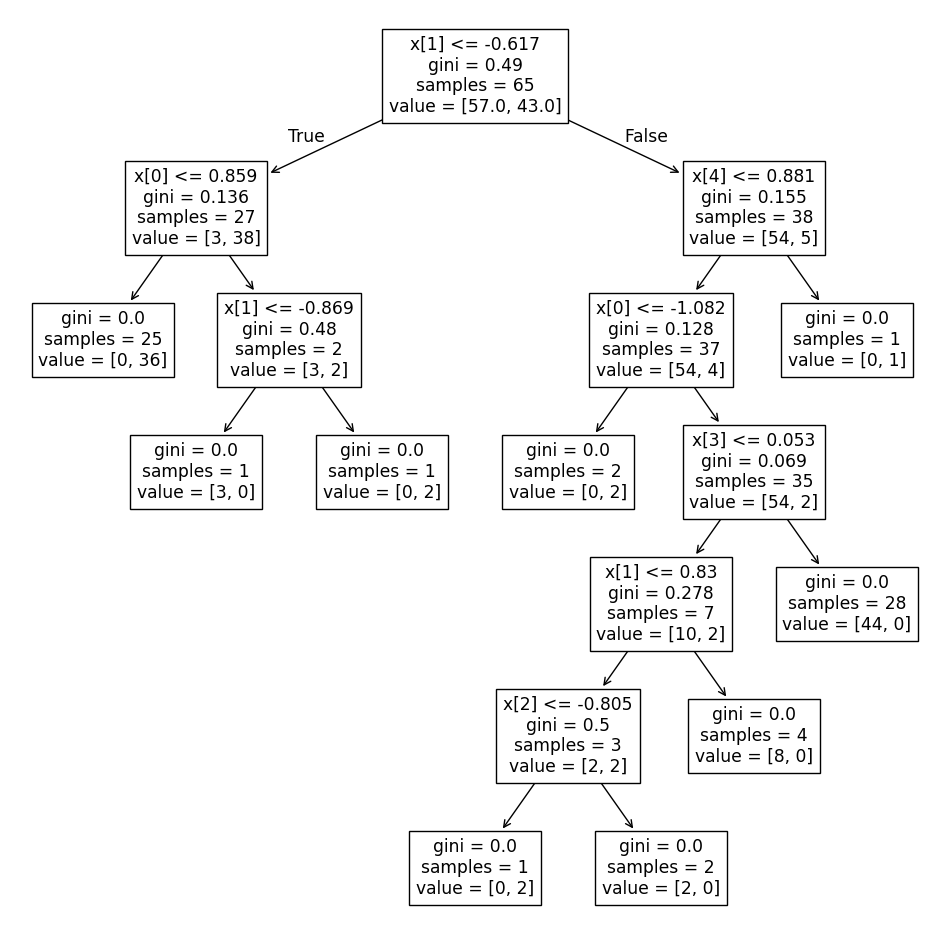

In [18]:
plt.figure(figsize=(12,12))
plot_tree(rf.estimators_[4])
plt.show()

as we can observe at each node different features were sampled and taken into consideration
- which further reduced correlation

- column sampling in bagging is tree level and rf is node level

> "RF doesn't overfit by adding trees, but it can overfit if individual trees are
> too deep on noisy data. The ensemble averages away some noise but not all.
> The irreducible overfitting floor is determined by ρ and per-tree bias, not n_estimators."
